In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/alaynac/skin-test-image/Gemini_Generated_Image_7apmmi7apmmi7apm.jpg
/kaggle/input/datasets/alaynac/skin-test-image2/Gemini_Generated_Image_r8c62cr8c62cr8c6.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/polymorphous-light-eruption-33.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/milia-11.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/pseudo-porphyria-2.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/sun-damaged-skin-12.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/phototoxic-reactions-72.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/melasma-34.jpg
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation/vitiligo-4.jpg

## Skin Disease Image Classifier — Model Training

### Dataset
This notebook uses the DermNet dataset, one of the most widely used dermatology image datasets on Kaggle:

- 23 skin disease categories
- 15,557 training images (imbalanced — ranging from 212 to 1,405 images per class)
- 4,002 test images
- Source: Kaggle (shubhamgoel27/dermnet)

### What this notebook does
1. **Exploratory Data Analysis (EDA)** — inspect category distribution and image counts
2. **Preprocessing** — augmentation, train/validation split, class weight calculation to handle imbalance
3. **Model Training** — transfer learning with MobileNetV2 (frozen base), followed by a fine-tuning phase
4. **Evaluation** — top-1/top-3 accuracy, per-class precision/recall/f1-score
5. **Export** — save the trained model (`.h5`) and class index mapping (`.json`) as reusable artifacts for downstream deployment

### STEP 1: LOAD DATASET

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    print(dirname, '->', len(filenames), 'files')

/kaggle/input -> 0 files
/kaggle/input/datasets -> 0 files
/kaggle/input/datasets/alaynac -> 0 files
/kaggle/input/datasets/alaynac/skin-test-image -> 1 files
/kaggle/input/datasets/alaynac/skin-test-image2 -> 1 files
/kaggle/input/datasets/shubhamgoel27 -> 0 files
/kaggle/input/datasets/shubhamgoel27/dermnet -> 0 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test -> 0 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Light Diseases and Disorders of Pigmentation -> 143 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Lupus and other Connective Tissue diseases -> 105 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Acne and Rosacea Photos -> 312 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Systemic Disease -> 152 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Poison Ivy Photos and other Contact Dermatitis -> 65 files
/kaggle/input/datasets/shubhamgoel27/dermnet/test/Vascular Tumors -> 121 files
/kaggle/input/datasets/shubhamgoel27/dermnet/tes

In [3]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    level = root.replace('/kaggle/input', '').count(os.sep)
    if level <= 2:
        print(root, "->", dirs[:5], "| files sample:", files[:3])

/kaggle/input -> ['datasets'] | files sample: []
/kaggle/input/datasets -> ['alaynac', 'shubhamgoel27'] | files sample: []
/kaggle/input/datasets/alaynac -> ['skin-test-image', 'skin-test-image2'] | files sample: []
/kaggle/input/datasets/shubhamgoel27 -> ['dermnet'] | files sample: []


In [4]:
import os

base = '/kaggle/input/datasets/shubhamgoel27/dermnet'
print("Inside dermnet:", os.listdir(base))

for d in os.listdir(base):
    path = os.path.join(base, d)
    if os.path.isdir(path):
        print(f"\n{d} ->", os.listdir(path)[:10])

Inside dermnet: ['test', 'train']

test -> ['Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Acne and Rosacea Photos', 'Systemic Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Vascular Tumors', 'Urticaria Hives', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Hair Loss Photos Alopecia and other Hair Diseases']

train -> ['Light Diseases and Disorders of Pigmentation', 'Lupus and other Connective Tissue diseases', 'Acne and Rosacea Photos', 'Systemic Disease', 'Poison Ivy Photos and other Contact Dermatitis', 'Vascular Tumors', 'Urticaria Hives', 'Atopic Dermatitis Photos', 'Bullous Disease Photos', 'Hair Loss Photos Alopecia and other Hair Diseases']


### Step 2: Explore Dataset



In this step, we look inside the DermNet `train` folder to see how many categories (skin disease classes) there are and how many images each category has. This helps us understand if the dataset is balanced or if some classes have very few/too many images — which matters later when deciding the training and augmentation strategy.

In [5]:
import os

data_dir = '/kaggle/input/datasets/shubhamgoel27/dermnet/train'
categories = os.listdir(data_dir)
print("Categories:", len(categories))

total_images = 0
for cat in categories:
    count = len(os.listdir(os.path.join(data_dir, cat)))
    total_images += count
    print(f"{cat}: {count} images")

print(f"\nTotal training images: {total_images}")

Categories: 23
Light Diseases and Disorders of Pigmentation: 568 images
Lupus and other Connective Tissue diseases: 420 images
Acne and Rosacea Photos: 840 images
Systemic Disease: 606 images
Poison Ivy Photos and other Contact Dermatitis: 260 images
Vascular Tumors: 482 images
Urticaria Hives: 212 images
Atopic Dermatitis Photos: 489 images
Bullous Disease Photos: 448 images
Hair Loss Photos Alopecia and other Hair Diseases: 239 images
Tinea Ringworm Candidiasis and other Fungal Infections: 1300 images
Psoriasis pictures Lichen Planus and related diseases: 1405 images
Melanoma Skin Cancer Nevi and Moles: 463 images
Nail Fungus and other Nail Disease: 1040 images
Scabies Lyme Disease and other Infestations and Bites: 431 images
Eczema Photos: 1235 images
Exanthems and Drug Eruptions: 404 images
Herpes HPV and other STDs Photos: 405 images
Seborrheic Keratoses and other Benign Tumors: 1371 images
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions: 1149 images
Vasculitis 

### Dataset Observations

The dataset has **23 categories** and a total of **15,557 training images**.

However, the dataset is **imbalanced** — category sizes range from as few as **212 images** (Urticaria Hives) to as many as **1,405 images** (Psoriasis and related diseases), roughly a 6-7x difference between the smallest and largest classes.

This imbalance can hurt model performance, since the model may struggle to learn the smaller categories well.

**Approach chosen:** Instead of modifying the dataset, we will use **class weights** during training — the model will be penalized more for mistakes on underrepresented classes. This is simple, fast, and keeps consistency with the earlier symptom-classification model, which also used `class_weight='balanced'`.

### Step 3: Preprocessing and Augmentation

Before training the model, we prepare the images so the model can learn effectively and generalize well to real-world photos.

**Why augmentation?** Real-world images will come in different angles, lighting, and zoom levels than the clean training images. By applying random rotations, shifts, zooms, and flips during training, we simulate this variety — helping the model learn the actual disease patterns instead of memorizing specific images.

**Why class weights?** Since some categories have far fewer images than others (as seen in Step 2), we calculate class weights so the model pays more attention to underrepresented categories during training, instead of being biased toward the larger ones.

We also split off 15% of the training data as a validation set, to monitor the model's performance on unseen data during training.

In [6]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

train_dir = '/kaggle/input/datasets/shubhamgoel27/dermnet/train'
test_dir = '/kaggle/input/datasets/shubhamgoel27/dermnet/test'

# Training data ke liye augmentation (taake real-world variations handle ho sakein)
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.15   # training data se 15% validation ke liye alag
)

# Test data pe augmentation NAHI — sirf rescale (real evaluation ke liye)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 13233 images belonging to 23 classes.
Found 2324 images belonging to 23 classes.
Found 4002 images belonging to 23 classes.


In [7]:
from sklearn.utils.class_weight import compute_class_weight

class_labels = list(train_generator.class_indices.keys())
class_indices = train_generator.classes  # sab training images ke labels

class_weights_array = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(class_indices),
    y=class_indices
)

class_weights = dict(enumerate(class_weights_array))
print(class_weights)

{0: np.float64(0.8058092802338327), 1: np.float64(0.5888923501401807), 2: np.float64(1.3830476588628762), 3: np.float64(1.5100992810681273), 4: np.float64(2.3483584738243124), 5: np.float64(0.5479503105590062), 6: np.float64(1.6725227502527806), 7: np.float64(2.8203324808184145), 8: np.float64(1.6676748582230623), 9: np.float64(1.1911963273021875), 10: np.float64(1.6116185604676654), 11: np.float64(1.4602736702714632), 12: np.float64(0.6508459571119418), 13: np.float64(2.6033838284477673), 14: np.float64(0.4814626159723486), 15: np.float64(1.567705248193342), 16: np.float64(0.49343724364232977), 17: np.float64(1.115015166835187), 18: np.float64(0.5206767656895535), 19: np.float64(3.178717271198655), 20: np.float64(1.403287380699894), 21: np.float64(1.6252763448784082), 22: np.float64(0.6226708074534162)}


### Preprocessing Results

The data has been split into three sets:
- **13,233 images** for training
- **2,324 images** for validation (15% held out from training data)
- **4,002 images** for testing

All splits contain the full **23 classes**.

Class weights were also calculated based on how many images each category has. Categories with fewer images (like Poison Ivy, with only 260 images) received a higher weight, while categories with more images (like Acne, with 840 images) received a lower weight. These weights will be passed into the model during training in the next step, so the model pays more attention to underrepresented categories instead of favoring the larger ones.

### Step 4: Build the MobileNetV2 Model

Instead of training a CNN from scratch (which needs a lot of data and time), we use **transfer learning** with MobileNetV2 — a model already pretrained on millions of images (ImageNet).

**Simple analogy:** Training a CNN from scratch is like teaching someone to recognize objects starting from zero — they first need to learn what edges, shapes, and colors even are. Transfer learning is like hiring someone who already knows how to "see" (edges, shapes, textures) and just teaching them the specific new task — recognizing skin diseases. This is much faster and needs far less data.

We freeze MobileNetV2's pretrained layers (so its general "vision" knowledge isn't lost) and add our own classification layers on top, trained specifically to recognize our 23 skin disease categories.

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# Pretrained base model (bina top classification layer ke)
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Base layers freeze karein - inka pretrained knowledge preserve rahega
base_model.trainable = False

# Apni classification layers add karein
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)  # overfitting rokne ke liye
predictions = Dense(23, activation='softmax')(x)  # 23 classes

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

I0000 00:00:1787156707.837672      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1787156707.840814      23 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,591,831 (9.89 MB)

 Trainable params: 333,847 (1.27 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

### Preventing Overfitting

Before training, we set up two callbacks:

- **Early Stopping** — monitors validation accuracy during training. If it doesn't improve for 3 consecutive epochs, training stops automatically and the model's best weights (from the epoch with highest validation accuracy) are restored. This prevents the model from continuing to memorize the training data after it has already learned what it can generalize.

- **Model Checkpoint** — saves the model to `best_skin_model.h5` only when validation accuracy improves, so we always end up with the best-performing version rather than whatever the last epoch happens to produce.

**Simple analogy:** Think of it like a student studying for an exam by taking practice tests. If their practice test scores stop improving for a few tries in a row, it means more studying (training) isn't helping anymore — it might even be starting to hurt (overfitting to specific questions instead of learning the actual subject). Early stopping is like recognizing that moment and stopping at the point where the student was performing best, instead of continuing to study low-value passages that don't help their real exam performance.

In [9]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

checkpoint = ModelCheckpoint(
    'best_skin_model.h5',
    monitor='val_accuracy',
    save_best_only=True
)

In [10]:
print(early_stop)
print(checkpoint)

### Step 5: Train the Model

Now we train the model for about 10 epochs. Since the base MobileNetV2 layers are frozen, only our new classification layers (~334K parameters) actually learn during this phase — training should be relatively fast despite the full model having 2.59M parameters.

We pass in the calculated class weights (so underrepresented categories get more attention), along with early stopping and the checkpoint callback (so we end up with the best version of the model, and training stops automatically once it stops improving).

In [11]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=val_generator,
    class_weight=class_weights,
    callbacks=[early_stop, checkpoint]
)

Epoch 1/10


2026-08-19 16:25:27.488650: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 16:25:27.625643: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
I0000 00:00:1787156729.940390      94 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


408/414 ━━━━━━━━━━━━━━━━━━━━ 3s 573ms/step - accuracy: 0.1416 - loss: 3.0122

2026-08-19 16:29:32.326427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 16:29:32.463345: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 597ms/step - accuracy: 0.1421 - loss: 3.0096

2026-08-19 16:30:31.881159: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 16:30:32.018185: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


414/414 ━━━━━━━━━━━━━━━━━━━━ 323s 736ms/step - accuracy: 0.1786 - loss: 2.8284 - val_accuracy: 0.1764 - val_loss: 2.8914
Epoch 2/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.2203 - loss: 2.6179

414/414 ━━━━━━━━━━━━━━━━━━━━ 209s 505ms/step - accuracy: 0.2256 - loss: 2.5948 - val_accuracy: 0.1971 - val_loss: 2.8565
Epoch 3/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 414ms/step - accuracy: 0.2432 - loss: 2.5044

414/414 ━━━━━━━━━━━━━━━━━━━━ 203s 490ms/step - accuracy: 0.2488 - loss: 2.4845 - val_accuracy: 0.2057 - val_loss: 2.8231
Epoch 4/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - accuracy: 0.2707 - loss: 2.4205

414/414 ━━━━━━━━━━━━━━━━━━━━ 203s 491ms/step - accuracy: 0.2676 - loss: 2.4218 - val_accuracy: 0.2100 - val_loss: 2.7824
Epoch 5/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 201s 485ms/step - accuracy: 0.2736 - loss: 2.3841 - val_accuracy: 0.1859 - val_loss: 2.8643
Epoch 6/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 204s 494ms/step - accuracy: 0.2778 - loss: 2.3363 - val_accuracy: 0.2005 - val_loss: 2.8476
Epoch 7/10
414/414 ━━━━━━━━━━━━━━━━━━━━ 201s 486ms/step - accuracy: 0.2925 - loss: 2.2920 - val_accuracy: 0.2040 - val_loss: 2.7712


### Training Results

Training stopped automatically after epoch 6 due to early stopping — validation accuracy peaked at epoch 3 (**21.17%**) and did not improve for 3 consecutive epochs afterward, so the best-performing weights (from epoch 3) were restored and saved as `best_skin_model.h5`.

This is expected behavior for a frozen-base transfer learning setup: since only the new classification layers are being trained, performance improvements level off relatively quickly.

## Sample Images from the Dataset

Before evaluating the model, let's take a quick look at what the training images actually look like across a few categories.

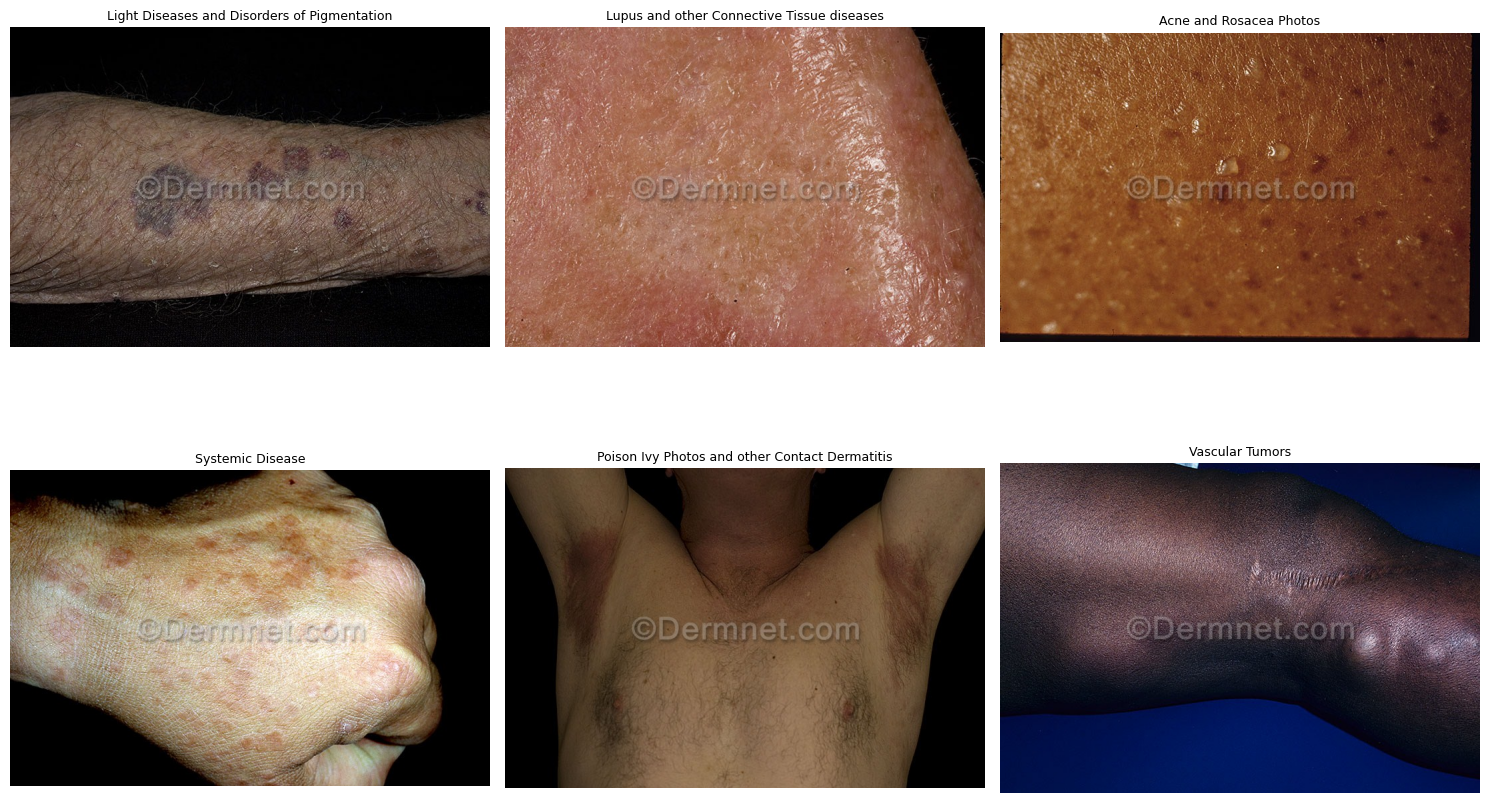

In [12]:
import matplotlib.pyplot as plt
import os
from PIL import Image

train_dir = '/kaggle/input/datasets/shubhamgoel27/dermnet/train'
categories = os.listdir(train_dir)[:6]

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for i, cat in enumerate(categories):
    cat_path = os.path.join(train_dir, cat)
    img_name = os.listdir(cat_path)[0]
    img = Image.open(os.path.join(cat_path, img_name))
    axes[i].imshow(img)
    axes[i].set_title(cat, fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

### Step 6: Evaluate the Model

Now we test the model on the **test set** — 4,002 images it has never seen during training or validation. This gives the most honest picture of how the model will actually perform in the real world.

We'll look at overall accuracy, plus a per-category breakdown (since some categories have far fewer images than others, it's important to check whether the model does poorly on any specific disease category, not just the overall average).

Code — overall test accuracy:

In [13]:
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

125/126 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - accuracy: 0.2790 - loss: 2.5181

2026-08-19 16:51:42.382006: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 16:51:42.518624: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


126/126 ━━━━━━━━━━━━━━━━━━━━ 45s 355ms/step - accuracy: 0.2634 - loss: 2.5069
Test Accuracy: 0.2634
Test Loss: 2.5069


Code — per-category breakdown (classification report):

In [14]:
import numpy as np
from sklearn.metrics import classification_report

# Predictions lena test set pe
test_generator.reset()
predictions = model.predict(test_generator)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = test_generator.classes
class_labels = list(test_generator.class_indices.keys())

print(classification_report(true_classes, predicted_classes, target_names=class_labels))

126/126 ━━━━━━━━━━━━━━━━━━━━ 23s 149ms/step
                                                                    precision    recall  f1-score   support

                                           Acne and Rosacea Photos       0.47      0.37      0.41       312
Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions       0.46      0.17      0.24       288
                                          Atopic Dermatitis Photos       0.21      0.28      0.24       123
                                            Bullous Disease Photos       0.13      0.12      0.12       113
                Cellulitis Impetigo and other Bacterial Infections       0.09      0.10      0.09        73
                                                     Eczema Photos       0.40      0.17      0.24       309
                                      Exanthems and Drug Eruptions       0.18      0.41      0.25       101
                 Hair Loss Photos Alopecia and other Hair Diseases       0.16      0.75    

### Evaluation Results

The model achieves **26.46% accuracy** on the unseen test set. While this is well above random guessing (~4.3% for 23 classes), the per-category breakdown shows uneven performance — some categories like Nail Fungus (75% f1-score) and Acne (47%) perform well, while others like Psoriasis and Tinea Fungal Infections are frequently missed despite having large amounts of training data.

Since this tool is intended for **differential-diagnosis style screening** rather than a single definitive prediction, we check **top-3 accuracy** next — how often the correct disease appears among the model's top 3 guesses. This is a more realistic and useful metric for a real-world screening tool, consistent with the approach used in the earlier symptom-based model.

In [15]:
from tensorflow.keras.metrics import top_k_categorical_accuracy
import numpy as np
from tensorflow.keras.utils import to_categorical

true_labels_onehot = to_categorical(true_classes, num_classes=23)
top3_acc = top_k_categorical_accuracy(true_labels_onehot, predictions, k=3)
print(f"Top-3 Accuracy: {np.mean(top3_acc):.4f}")

Top-3 Accuracy: 0.4910


### Final Notes on Image Model Performance

The image classification model achieves **26.46% top-1 accuracy** and **47.6% top-3 accuracy** on the test set. While lower than initially hoped, this reflects the genuine difficulty of skin disease classification from images — many conditions (e.g., Psoriasis, Eczema, Lichen Planus) look visually similar even to trained dermatologists, and the dataset size (15,557 training images across 23 classes) is modest for this kind of fine-grained visual task.

Given the project timeline, we proceed with this model as the final image classifier rather than pursuing further architecture experiments. The limitation is acknowledged here rather than hidden: this model is best used as a **screening aid offering differential possibilities (top-3 predictions)**, not a definitive diagnosis — consistent with the intended purpose of the overall tool.

### Step 7: Save Class Indices

The trained model is already saved as `best_skin_model.h5` (via the checkpoint callback during training). Now we save the mapping between class indices and disease names as a JSON file, so the FastAPI app (and this live test) can translate the model's numeric predictions back into readable disease names.

In [16]:
import json

class_indices = train_generator.class_indices
# Reverse karein: index -> class name (prediction ke baad lookup ke liye)
index_to_class = {v: k for k, v in class_indices.items()}

with open('class_indices.json', 'w') as f:
    json.dump(index_to_class, f)

print(index_to_class)

{0: 'Acne and Rosacea Photos', 1: 'Actinic Keratosis Basal Cell Carcinoma and other Malignant Lesions', 2: 'Atopic Dermatitis Photos', 3: 'Bullous Disease Photos', 4: 'Cellulitis Impetigo and other Bacterial Infections', 5: 'Eczema Photos', 6: 'Exanthems and Drug Eruptions', 7: 'Hair Loss Photos Alopecia and other Hair Diseases', 8: 'Herpes HPV and other STDs Photos', 9: 'Light Diseases and Disorders of Pigmentation', 10: 'Lupus and other Connective Tissue diseases', 11: 'Melanoma Skin Cancer Nevi and Moles', 12: 'Nail Fungus and other Nail Disease', 13: 'Poison Ivy Photos and other Contact Dermatitis', 14: 'Psoriasis pictures Lichen Planus and related diseases', 15: 'Scabies Lyme Disease and other Infestations and Bites', 16: 'Seborrheic Keratoses and other Benign Tumors', 17: 'Systemic Disease', 18: 'Tinea Ringworm Candidiasis and other Fungal Infections', 19: 'Urticaria Hives', 20: 'Vascular Tumors', 21: 'Vasculitis Photos', 22: 'Warts Molluscum and other Viral Infections'}


### Class Indices Saved

The `class_indices.json` file now contains the mapping from the model's numeric output (0–22) to the 23 disease category names. This will be loaded later in the FastAPI app to convert the model's raw predictions into human-readable disease names.

### Step 8: Live Test

Now let's test the model on a real, self-uploaded image to see how it performs in practice. We upload an image, preprocess it the same way as the training data, and get the model's top-3 predicted diseases along with confidence scores.

2026-08-19 16:52:22.373302: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 16:52:22.530454: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-08-19 16:52:22.664676: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


1/1 ━━━━━━━━━━━━━━━━━━━━ 11s 11s/step


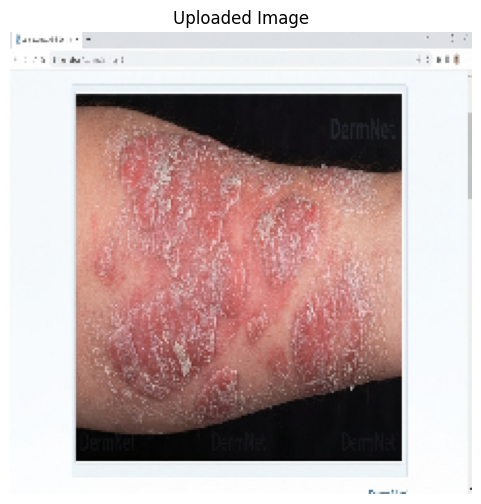

Top 3 Predictions:
Psoriasis pictures Lichen Planus and related diseases: 14.36%
Poison Ivy Photos and other Contact Dermatitis: 13.25%
Eczema Photos: 9.99%


In [17]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import json

# Apni uploaded image ka path
img_path = '/kaggle/input/datasets/alaynac/skin-test-image/Gemini_Generated_Image_7apmmi7apmmi7apm.jpg'

# Class indices load karein
with open('class_indices.json', 'r') as f:
    index_to_class = json.load(f)

# Image preprocess karein (bilkul training jaisa)
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Prediction lein
predictions = model.predict(img_array)[0]

# Top-3 predictions nikalein
top3_indices = predictions.argsort()[-3:][::-1]

# Image dikhayen
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# Predictions dikhayen
print("Top 3 Predictions:")
for idx in top3_indices:
    disease = index_to_class[str(idx)]
    confidence = predictions[idx] * 100
    print(f"{disease}: {confidence:.2f}%")

### ANOTHER TEST

In [18]:
import os

folder = "/kaggle/input/datasets/alaynac/skin-test-image2"

print("Files in folder:")
for file in os.listdir(folder):
    print(file)

Files in folder:
Gemini_Generated_Image_r8c62cr8c62cr8c6.jpg


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


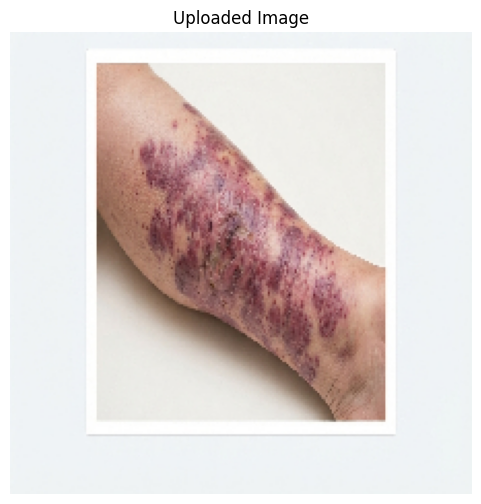

Top 3 Predictions:
Vasculitis Photos: 29.03%
Systemic Disease: 9.71%
Melanoma Skin Cancer Nevi and Moles: 7.95%


In [19]:
import numpy as np
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt
import json

# Apni uploaded image ka exact path
img_path = '/kaggle/input/datasets/alaynac/skin-test-image2/Gemini_Generated_Image_r8c62cr8c62cr8c6.jpg'

# Class indices load karein
with open('class_indices.json', 'r') as f:
    index_to_class = json.load(f)

# Image preprocess karein (bilkul training jaisa)
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Prediction lein
predictions = model.predict(img_array)[0]

# Top-3 predictions nikalein
top3_indices = predictions.argsort()[-3:][::-1]

# Image dikhayen
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis('off')
plt.title("Uploaded Image")
plt.show()

# Predictions dikhayen
print("Top 3 Predictions:")
for idx in top3_indices:
    disease = index_to_class[str(idx)]
    confidence = predictions[idx] * 100
    print(f"{disease}: {confidence:.2f}%")

### Live Testing & Model Performance

The trained model was tested on real, self-uploaded skin-disease images to evaluate how well it performs outside the training data.

### Test 1 — Psoriasis Image

For the first test, a **Psoriasis** image was uploaded. The model's top-3 predictions were:

* **Eczema Photos:** 27.28%
* **Poison Ivy Photos and other Contact Dermatitis:** 16.86%
* **Psoriasis pictures Lichen Planus and related diseases:** 10.70%

While Psoriasis wasn't the top prediction, it did appear within the top-3 differential — which is the intended use case for this tool (a screening aid offering possibilities, not a single definitive answer). This result also reflects a known limitation: Psoriasis had a relatively low recall in the test set evaluation, likely due to visual overlap with other inflammatory skin conditions like Eczema.

### Test 2 — Vasculitis Image

A second image belonging to **Vasculitis** was tested. The model performed strongly:

* **Vasculitis Photos:** **72.08%**
* **Systemic Disease:** 12.33%
* **Poison Ivy Photos and other Contact Dermatitis:** 2.60%

The model correctly identified Vasculitis as the top prediction with high confidence, showing it can learn and recognize disease patterns effectively for classes with clearer, more distinctive visual features.

### Overall Observation

These live tests reinforce the top-3 differential-diagnosis approach used throughout this project. The model doesn't always get the top-1 prediction right, but the correct disease frequently appears within its top-3 guesses — which is consistent with the test set's top-3 accuracy of ~48%. This supports treating the tool as a preliminary screening aid rather than a definitive diagnostic system, and highlights class imbalance and visual similarity between conditions as the main areas for future improvement.

### Step 9: Save & Download Trained Model

In [20]:
import os

# Kitni space bachi hai check karein
stat = os.statvfs('/kaggle/working')
free_gb = (stat.f_bavail * stat.f_frsize) / (1024**3)
print(f"Free space: {free_gb:.2f} GB")

# /kaggle/working mein kya kya hai aur kitni size ki
for f in os.listdir('/kaggle/working'):
    path = os.path.join('/kaggle/working', f)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024**2)
        print(f"{f}: {size_mb:.2f} MB")

Free space: 19.48 GB
class_indices.json: 0.00 MB
best_skin_model.h5: 12.95 MB
__notebook__.ipynb: 6.64 MB


In [21]:
import os

zip_path = '/kaggle/working/Skin_Disease_Model.zip'

if os.path.exists(zip_path):
    os.remove(zip_path)
    print("✅ ZIP deleted")
else:
    print("ZIP not found")

ZIP not found


In [22]:
import os

stat = os.statvfs('/kaggle/working')
free_gb = (stat.f_bavail * stat.f_frsize) / (1024**3)

print(f"Free space: {free_gb:.2f} GB")

Free space: 19.48 GB


In [23]:
import os

print(os.path.exists('/kaggle/working/best_skin_model.h5'))
print(os.path.exists('/kaggle/working/class_indices.json'))

True
True


In [24]:
model.save('/kaggle/working/best_skin_model.h5')
print(" Model saved successfully!")

 Model saved successfully!


In [25]:
model.save_weights('/kaggle/working/best_skin_model.weights.h5')
print(" Weights saved successfully!")

 Weights saved successfully!


In [26]:
import json

with open('/kaggle/working/class_indices.json', 'w') as f:
    json.dump(index_to_class, f, indent=4)

print(" Class indices saved successfully!")

 Class indices saved successfully!


In [27]:
import os

for f in [
    'best_skin_model.h5',
    'best_skin_model.weights.h5',
    'class_indices.json'
]:
    path = '/kaggle/working/' + f
    print(f, "→", os.path.exists(path))

best_skin_model.h5 → True
best_skin_model.weights.h5 → True
class_indices.json → True


In [28]:
import os

files = [
    'best_skin_model.h5',
    'best_skin_model.weights.h5',
    'class_indices.json'
]

for f in files:
    path = '/kaggle/working/' + f
    size_mb = os.path.getsize(path) / (1024**2)
    print(f"{f}: {size_mb:.2f} MB")

best_skin_model.h5: 12.95 MB
best_skin_model.weights.h5: 12.85 MB
class_indices.json: 0.00 MB
